# Early Sepsis Prediction Using Deep Learning on MIMIC-III

## Overview

This notebook implements an end-to-end **time-series deep learning pipeline** for early sepsis prediction using the **MIMIC-III Clinical Database**.

### Clinical Goal
Sepsis is a life-threatening organ dysfunction caused by a dysregulated response to infection. Every hour of delayed treatment increases mortality by approximately 7%. This notebook attempts to **predict sepsis onset 12 hours before it occurs**, using the preceding 48 hours of ICU vital signs and lab results.

### Models Compared
| Model | Type | Input |
|---|---|---|
| **XGBoost** | Gradient Boosted Trees (Baseline) | Aggregate statistics over 48h window |
| **LSTM** | Recurrent Deep Learning | Full 48-timestep sequence (48 × 80 features) |
| **Transformer** | Self-Attention Deep Learning | Full 48-timestep sequence with CLS token |

### Key Design Decisions
- **Sepsis-3 labelling**: infection (antibiotic proxy) + organ dysfunction (SOFA proxy)
- **Onset-only label**: only the *first* timestep where criteria are met is marked positive — teaching the model to predict future onset, not identify existing disease
- **Patient-level train/test split**: prevents data leakage from overlapping sliding windows
- **Apple M3 MPS acceleration**: enables GPU-speed training on local hardware


### Import Libraries

We import libraries for:
- **Data processing**: `pandas`, `numpy`
- **Visualisation**: `matplotlib`
- **Machine learning**: `scikit-learn` (metrics, preprocessing, splitting), `xgboost`
- **Deep learning**: `PyTorch` (neural network framework with MPS GPU support)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)

from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import random, os


### Set Seed values for reproducibility

In [2]:
# Set a fixed random seed for reproducibility across all models and libraries

SEED = 42  

def set_global_seed(seed):
    """Fix all sources of randomness for full reproducibility."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_global_seed(SEED)
print(f"All random seeds fixed to {SEED}")

All random seeds fixed to 42


---
## 1. Load MIMIC-III Data

MIMIC-III (Medical Information Mart for Intensive Care) is a publicly available ICU database from MIT containing over 50,000 admissions.

### Tables Used
| Table | Purpose |
|---|---|
| `PATIENTS` | Demographics (DOB, gender, DOD) |
| `ADMISSIONS` | Hospital admission/discharge times |
| `ICUSTAYS` | ICU unit and duration |
| `PRESCRIPTIONS` | Drug orders — used to identify **antibiotic administration** as infection proxy |
| `CHARTEVENTS` | Timestamped vital sign measurements |
| `LABEVENTS` | Laboratory test results |


**Note**: `CHARTEVENTS` is extremely large. We only load the columns we need and filter to required ITEMIDs immediately after loading.

In [3]:
import os

# Update this path to your local MIMIC-III directory
data_path = "../../../Documents/Learning/MS_AI/AI_In_Healthcare/Dataset/mimic-iii-clinical-database-1.4/"
print(os.path.exists(data_path))  # Should print True


True


In [4]:
folder_name = "images"

# Create images folder if it doesn't exist. This is where we'll save all our plots.
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

print(f"Folder '{folder_name}' exists.")

Folder 'images' exists.


In [5]:
# ── Core demographic / administrative tables ──────────────────────────────
# These are small and load quickly
patients   = pd.read_csv(data_path + "PATIENTS.csv.gz")
admissions = pd.read_csv(data_path + "ADMISSIONS.csv.gz")
icustays   = pd.read_csv(data_path + "ICUSTAYS.csv.gz")

# ── Prescriptions: used to identify antibiotic start date ─────────────────
# We only need HADM_ID (admission), DRUG (name), STARTDATE (when given)
# low_memory=False avoids mixed-type warnings on large files
prescriptions = pd.read_csv(
    data_path + "PRESCRIPTIONS.csv.gz",
    usecols=["HADM_ID", "DRUG", "STARTDATE", "DOSE_VAL_RX"],
    low_memory=False
)

# Dose values are stored as strings (e.g. '500', 'unknown') — coerce to numeric
# errors='coerce' turns unparseable strings into NaN instead of raising an error
prescriptions["DOSE_VAL_RX"] = pd.to_numeric(
    prescriptions["DOSE_VAL_RX"], errors="coerce"
)

# ── ChartEvents: vital signs ───────────────────────────────────────────────
# This is the largest table (~3 GB). We load only the 5 columns we need.
# parse_dates converts CHARTTIME from string to datetime — required for resampling
chartevents = pd.read_csv(
    data_path + "CHARTEVENTS.csv.gz",
    usecols=["SUBJECT_ID", "HADM_ID", "ITEMID", "VALUENUM", "CHARTTIME"],
    parse_dates=["CHARTTIME"],
    compression="gzip"
)

# ── LabEvents: lab test results ────────────────────────────────────────────
labevents = pd.read_csv(
    data_path + "LABEVENTS.csv.gz",
    usecols=["SUBJECT_ID", "HADM_ID", "ITEMID", "VALUENUM", "CHARTTIME"],
    parse_dates=["CHARTTIME"]
)


---
## 2. Feature Engineering

### 2.1 Sepsis-3 Clinical Definition

We follow the **Sepsis-3 consensus definition** (Singer et al., JAMA 2016 doi:10.1001/jama.2016.0287):

> **Sepsis = Suspected Infection + Organ Dysfunction (SOFA score increase ≥ 2)**

### MIMIC-III Approximation Strategy

| Sepsis-3 Component | MIMIC-III Proxy |
|---|---|
| Suspected Infection | First antibiotic administration date (from `PRESCRIPTIONS`) |
| Organ Dysfunction (SOFA ≥ 2) | Creatinine > 2.0 mg/dL (renal) **OR** Platelets < 100 K/µL (coagulation) |


**Known limitation**: The full SOFA score uses 6 organ systems (respiratory, neurological, hepatic, cardiovascular, renal, coagulation). We implement only 2. This causes the sepsis rate to be higher than published cohorts (~15–20%). Full SOFA implementation would improve label quality.


In [6]:
# ── 2.1 Infection Flag: Antibiotic Proxy ─────────────────────────────────
#
# Sepsis-3 requires 'suspected infection'. We approximate this using the
# first antibiotic prescription date per hospital admission.
# This is a common MIMIC-III proxy used in published sepsis research.

# List of broad-spectrum antibiotics commonly used for serious infections.
# We cast to lowercase to handle mixed capitalisation in the DRUG column.
antibiotics = [
    "vancomycin",    # MRSA, gram-positive coverage
    "cefepime",      # broad gram-negative/positive
    "piperacillin",  # anti-pseudomonal penicillin
    "meropenem",     # carbapenem, very broad spectrum
    "zosyn",         # piperacillin-tazobactam combination
    "ceftriaxone",   # 3rd gen cephalosporin
    "ceftazidime",   # anti-pseudomonal cephalosporin
    "azithromycin",  # atypical pneumonia coverage
    "levofloxacin",  # respiratory fluoroquinolone
    "ciprofloxacin", # fluoroquinolone, GI/urinary infections
    "ampicillin",    # broad-spectrum penicillin
    "amoxicillin",   # oral penicillin
    "clindamycin",   # anaerobic coverage
    "linezolid",     # MRSA / VRE coverage
    "doxycycline",   # atypical organisms
    "metronidazole"  # anaerobic / C. diff coverage
]

prescriptions["drug_lower"] = prescriptions["DRUG"].str.lower()

# Filter to rows where the drug name contains any antibiotic string
# na=False: treat NaN drug names as non-matching (safe to skip)
abx = prescriptions[
    prescriptions["drug_lower"].str.contains('|'.join(antibiotics), na=False)
]

abx = abx.copy()
abx["STARTDATE"] = pd.to_datetime(abx["STARTDATE"])

# For each admission, record the EARLIEST antibiotic start date.
# This represents the moment clinicians first suspected infection.
infection_time = (
    abx.groupby("HADM_ID")["STARTDATE"]
    .min()
    .reset_index()
    .rename(columns={"STARTDATE": "infection_time"})
)


### 2.2 Clinical Indicator Item IDs

MIMIC-III uses **ITEMID** codes to identify measurements in CHARTEVENTS and LABEVENTS. Each vital sign or lab test has one or more ITEMIDs depending on which ICU system recorded it (CareVue vs MetaVision).

| Feature | ITEMID(s) | Clinical Relevance |
|---|---|---|
| SpO2 | 220277, 646 | Oxygen saturation — respiratory SOFA proxy |
| MAP | 220181, 220052 | Mean arterial pressure — cardiovascular SOFA |
| GCS | 223901, 220739 | Glasgow Coma Scale — neurological SOFA |
| FiO2 | 223835, 3420 | Fraction of inspired O₂ — PaO₂/FiO₂ ratio |
| Creatinine | 50912 | Renal dysfunction (SOFA: >2.0 mg/dL = score 2+) |
| Platelets | 51265 | Coagulation (SOFA: <100 K/µL = score 2+) |
| Lactate | 50813 | Tissue perfusion — strongest predictor of septic shock |
| WBC | 51300 | White cell count — infection/inflammation marker |


In [7]:
# ── 2.2 ITEMID constants ──────────────────────────────────────────────────
#
# Using named constants (rather than raw numbers throughout the code) makes
# the code self-documenting and easier to update if ITEMIDs change.

# Vitals from CHARTEVENTS
SPO2_IDS = [220277, 646]        # SpO2: MetaVision + CareVue
MAP_IDS  = [220181, 220052]     # MAP: non-invasive + invasive arterial
GCS_IDS  = [223901, 220739]     # GCS total: motor + verbal/eye combined
FIO2_IDS = [223835, 3420]       # FiO2: MetaVision + CareVue

# Labs from LABEVENTS
CREATININE_ID = 50912   # mg/dL — renal function
PLATELETS_ID  = 51265   # K/µL  — coagulation
LACTATE_ID    = 50813   # mmol/L — tissue perfusion (>2 = elevated)
WBC_ID        = 51300   # K/µL  — immune response / infection marker


### 2.3 Organ Dysfunction Score (Simplified SOFA Proxy)

We compute two binary flags for organ dysfunction:
- **Renal**: peak creatinine > 2.0 mg/dL during the admission
- **Coagulation**: minimum platelets < 100 K/µL during the admission

A patient scores `organ_dysfunction = 1` if **either** criterion is met (equivalent to SOFA sub-score ≥ 2 for that domain).

We also extract **Lactate** and **WBC** as time-varying features (not just as threshold flags) because their trend over time is clinically important — rising lactate is more alarming than stable elevated lactate.


In [8]:
# ── 2.3 Organ Dysfunction — Simplified SOFA Proxy ─────────────────────────
labs = labevents.copy()

# Creatinine: renal dysfunction
# We use the MAXIMUM value across the admission (worst-case kidney function)
# Threshold > 2.0 mg/dL = SOFA renal score of 2 or higher
creatinine = (
    labs[labs["ITEMID"] == CREATININE_ID]
    .groupby("HADM_ID")["VALUENUM"].max()
    .reset_index()
)
creatinine["renal"] = (creatinine["VALUENUM"] > 2.0).astype(int)

# Platelets: coagulation dysfunction
# We use the MINIMUM value (worst-case platelet count)
# Threshold < 100 K/µL = SOFA coagulation score of 2 or higher
platelets = (
    labs[labs["ITEMID"] == PLATELETS_ID]
    .groupby("HADM_ID")["VALUENUM"].min()
    .reset_index()
)
platelets["coag"] = (platelets["VALUENUM"] < 100).astype(int)

# Lactate: time-varying lab feature (kept per timestamp, not aggregated)
# Lactate > 2 mmol/L indicates impaired tissue perfusion (septic shock criterion)
# We average if multiple measurements were taken at the same timestamp
lactate = (
    labs[labs["ITEMID"] == LACTATE_ID]
    .groupby(["HADM_ID", "CHARTTIME"])["VALUENUM"]
    .mean().reset_index()
    .rename(columns={"VALUENUM": "Lactate"})
)

# WBC: time-varying lab feature (kept per timestamp)
# Elevated WBC (>12 K/µL) or low WBC (<4 K/µL) both indicate systemic response
wbc = (
    labs[labs["ITEMID"] == WBC_ID]
    .groupby(["HADM_ID", "CHARTTIME"])["VALUENUM"]
    .mean().reset_index()
    .rename(columns={"VALUENUM": "WBC"})
)

# ── Combine into SOFA summary per admission ────────────────────────────────
# outer merge: keep all admissions even if one lab is missing
# fillna(0): missing lab = assume no dysfunction detected
sofa = creatinine.merge(platelets, on="HADM_ID", how="outer").fillna(0)
sofa["sofa_score"] = sofa["renal"] + sofa["coag"]  # max possible = 2

# organ_dysfunction = 1 if ANY organ system meets the threshold
# (equivalent to SOFA increase ≥ 1 in our 2-domain approximation)
sofa["organ_dysfunction"] = (sofa["sofa_score"] >= 1).astype(int)


### 2.4 Vital Sign Extraction

We extract 9 vital signs from CHARTEVENTS. Each vital may have multiple ITEMIDs because MIMIC-III stores data from two different ICU systems:
- **CareVue** (older, pre-2011): lower ITEMID numbers
- **MetaVision** (newer): higher ITEMID numbers (often 220xxx)

We merge measurements from both systems and average if both recorded a value at the same timestamp.

Lab features (Lactate, WBC) are merged in as additional time-varying columns, giving us **13 base features** before derived feature engineering.


In [9]:
# ── 2.4 Vital Sign Extraction ─────────────────────────────────────────────

# Mapping: feature name → list of ITEMID codes
# Multiple ITEMIDs per feature = same measurement recorded by different ICU systems
vital_ids = {
    "HR":   [211, 220045],   # Heart rate (bpm) — tachycardia common in sepsis
    "SBP":  [220179],        # Systolic blood pressure (mmHg)
    "DBP":  [220180],        # Diastolic blood pressure (mmHg)
    "RR":   [220210],        # Respiratory rate (breaths/min) — tachypnea in sepsis
    "Temp": [223761],        # Temperature (°F) — fever or hypothermia in sepsis
    "SpO2": SPO2_IDS,        # Oxygen saturation (%) — respiratory failure marker
    "MAP":  MAP_IDS,         # Mean arterial pressure (mmHg) — perfusion pressure
    "GCS":  GCS_IDS,         # Glasgow Coma Scale (3-15) — neurological status
    "FIO2": FIO2_IDS,        # Fraction of inspired O2 (%) — ventilator/O2 therapy
}

def extract_vitals(df):
    """Extract each vital sign from chartevents and merge into one wide dataframe.
    
    For each vital, we:
    1. Filter to relevant ITEMIDs
    2. Average across ITEMIDs if multiple recorded at the same time
    3. Merge all vitals together using an outer join on (HADM_ID, CHARTTIME)
    """
    dfs = []
    for name, ids in vital_ids.items():
        temp = df[df["ITEMID"].isin(ids)]
        # Average if multiple ITEMIDs recorded different values at the same time
        temp = temp.groupby(["HADM_ID", "CHARTTIME"])["VALUENUM"].mean().reset_index()
        temp = temp.rename(columns={"VALUENUM": name})
        dfs.append(temp)

    # Outer merge: keep all timestamps, even if some vitals are missing
    from functools import reduce
    merged = reduce(
        lambda left, right: pd.merge(left, right, on=["HADM_ID", "CHARTTIME"], how="outer"),
        dfs
    )
    return merged

vitals = extract_vitals(chartevents)

# ── Merge time-varying lab features into vitals ────────────────────────────
# Outer join: keeps timestamps where either labs OR vitals were recorded
from functools import reduce
vitals = reduce(
    lambda left, right: pd.merge(left, right, on=["HADM_ID", "CHARTTIME"], how="outer"),
    [vitals, lactate, wbc]
)
# Result: one row per (admission, timestamp), 11 feature columns (9 vitals + Lactate + WBC)


##### Resample to Hourly Sequences


In [10]:
# ── Hourly Resampling ────────────────────────────────────────────────────
#
# Problem: ICU measurements are NOT at regular intervals. A patient may have
# HR measured every 15 min, SpO2 every hour, and labs only twice a day.
#
# Solution: Resample to a uniform 1-hour grid. This is required for LSTM and
# Transformer, which expect fixed-length sequences with consistent time spacing.
#
# Strategy:
#   - resample('1h').mean(): average all measurements within each 1-hour bin
#   - ffill(): forward-fill gaps with the most recent known value
#   - bfill(): backward-fill any remaining gaps at the start of the admission

# Sort by patient and time — required before groupby+resample
vitals = vitals.sort_values(["HADM_ID", "CHARTTIME"])

# Keep only numeric columns (drop any string columns that slipped in)
numeric_cols = vitals.select_dtypes(include=["number"]).columns.tolist()

# HADM_ID is numeric but we need it as the groupby key, ensure it's included
if "HADM_ID" not in numeric_cols:
    numeric_cols = ["HADM_ID"] + numeric_cols

# Vectorised resampling — faster than a Python loop over each admission
vitals_resampled = (
    vitals[numeric_cols + ["CHARTTIME"]]
    .set_index(["HADM_ID", "CHARTTIME"])  # multi-index required for groupby+resample
    .groupby(level=0)                      # group by patient
    .resample("1h", level=1)               # bin timestamps into 1-hour buckets
    .mean()                                # average values within each hour
    .groupby(level=0)                      # group again for fill operations
    .ffill().bfill()                        # fill gaps: forward first, then backward
    .reset_index()
)
# Result: each patient has exactly one row per hour, with all feature columns filled


### 2.5 Time-Sensitive Sepsis Labelling

We create per-row (per-hour) sepsis labels by combining:
1. **Infection flag**: is this hour within 6 hours AFTER antibiotic start?
2. **Organ dysfunction**: did this patient ever meet renal or coagulation criteria?

A row is labelled `sepsis = 1` if both conditions are true simultaneously.


**Important design choice**: We sampled 2,000 admissions for tractable local training. The full MIMIC-III cohort (~50,000 admissions) would require Google Colab GPU training.


In [11]:
# ── 2.5 Build Per-Row Sepsis Labels ──────────────────────────────────────

# Step 1: Merge infection time onto the hourly vitals table
# left join: keep all hours; infection_time = NaN for patients with no antibiotics
labels_td = vitals_resampled.merge(infection_time, on="HADM_ID", how="left")

# ── Sample 2,000 admissions for tractable local training ─────────────────
# The full MIMIC-III cohort has ~50,000 admissions.
# We sample 2,000 to enable training on Apple M3 hardware within a reasonable time.
# When running on Google Colab with a GPU, use the full cohort.
selected_ids = labels_td["HADM_ID"].drop_duplicates().sample(n=2000, random_state=SEED)
labels_td = labels_td[labels_td["HADM_ID"].isin(selected_ids)]

labels_td["infection_time"] = pd.to_datetime(labels_td["infection_time"])

# Step 2: Infection flag
# A row is 'infected' if:
#   (a) the patient has an antibiotic start time (infection_time is not NaN), AND
#   (b) the current hour is >= (antibiotic_start - 6h)
#
# The 6-hour look-back window accounts for the fact that infection was likely
# present before the antibiotic was ordered.
labels_td["infection"] = (
    (labels_td["infection_time"].notna()) &
    (labels_td["CHARTTIME"] >= labels_td["infection_time"] - pd.Timedelta(hours=6))
).astype(int)

# Step 3: Merge organ dysfunction flag (one value per admission, broadcast to all rows)
labels_td = labels_td.merge(
    sofa[["HADM_ID", "organ_dysfunction"]],
    on="HADM_ID",
    how="left"
)
labels_td["organ_dysfunction"] = labels_td["organ_dysfunction"].fillna(0)

# Step 4: Sepsis = BOTH infection AND organ dysfunction
# This implements Sepsis-3: suspected infection + SOFA increase
labels_td["sepsis"] = (
    (labels_td["infection"] == 1) &
    (labels_td["organ_dysfunction"] == 1)
).astype(int)


### 2.6 Sepsis Onset Flag — Teaching Early Warning, Not Disease Identification

A critical distinction:
- **`sepsis` column**: marks *every row* as 1 once criteria are met — the model would learn to identify already-existing sepsis
- **`sepsis_onset` column**: marks *only the first timestep* where criteria are met — the model learns to predict *when sepsis will begin*

Using `sepsis_onset` in the sliding window target forces the model to only receive a positive label for windows where onset **occurs in the future horizon** (not the past).


In [12]:
# ── 2.6 First-Onset Label ─────────────────────────────────────────────────
#
# Why this matters:
# If we use the raw 'sepsis' column, a window that CONTAINS the onset moment
# gets labeled positive. The model learns: 'this sequence shows sepsis'.
# If we use 'sepsis_onset', only windows where onset falls in the NEXT
# pred_horizon hours are labeled positive. The model learns:
# 'sepsis is about to happen in the next 12 hours' — the actual clinical goal.

def first_onset(group):
    """Return a Series of zeros with a single 1.0 at the first sepsis-positive row.
    
    If the group has no sepsis row, returns all zeros.
    This 'onset moment' label is what we use in the sliding window target.
    """
    onset = np.zeros(len(group), dtype=np.float32)

    # argmax on a boolean Series returns the INDEX of the first True value.
    # If no True exists, argmax returns 0 — so we guard with .any() first.
    idx = (group["sepsis"] == 1).values.argmax() if (group["sepsis"] == 1).any() else -1

    if idx >= 0:
        onset[idx] = 1.0  # mark only the FIRST positive hour
    return pd.Series(onset, index=group.index)

labels_td["sepsis_onset"] = (
    labels_td.groupby("HADM_ID", group_keys=False)
    .apply(first_onset, include_groups=False)
)


In [13]:
# ── No-infection fallback ─────────────────────────────────────────────────
#
# Patients with no antibiotic prescription have infection_time = NaN.
# These patients should be labeled sepsis = 0 (no infection evidence).
#
# For example, a patient can have renal failure without sepsis. This fix corrects that label corruption.
labels_td.loc[
    labels_td["infection_time"].isna(),
    "sepsis"
] = 0


In [14]:
# ── Sanity check: verify sepsis rate is plausible ─────────────────────────
# Published MIMIC-III sepsis cohorts report ~15-20% of ICU admissions.
# Row-level rates are higher because each admission has many rows.
# A rate above 40% suggests the SOFA proxy is over-labelling.
print("Sepsis-positive rows:", labels_td["sepsis"].sum())
print("Sepsis rate (row-level):", labels_td["sepsis"].mean().round(4))


Sepsis-positive rows: 93498
Sepsis rate (row-level): 0.3234


### 2.7 Clinical Derived Features

Beyond the raw measurement values, we engineer two additional clinical features from lactate:
- **`lactate_high`**: binary flag — lactate > 2 mmol/L is the threshold for septic shock screening in Sepsis-3
- **`lactate_trend`**: hour-over-hour change — *rising* lactate is more clinically alarming than stable elevated lactate


In [15]:
# ── 2.7 Lactate-Specific Clinical Features ───────────────────────────────

# Binary flag: lactate above the Sepsis-3 shock screening threshold
# Lactate > 2 mmol/L = abnormal, warrants further assessment
# Lactate > 4 mmol/L = septic shock (even without hypotension)
labels_td["lactate_high"] = (labels_td["Lactate"] > 2).astype(int)

# Trend: hour-over-hour change in lactate within each admission
# diff() computes: current_value - previous_value
# Positive trend = rising lactate (deterioration signal)
# Negative trend = clearing lactate (improvement)
# groupby ensures we don't compute diffs across patient boundaries
labels_td["lactate_trend"] = (
    labels_td.groupby("HADM_ID")["Lactate"].diff()
)


In [16]:
# ── Handle missing values globally ────────────────────────────────────────
#
# After all feature engineering, some cells may still be NaN or Inf.
# We apply a three-step cleaning:
#   1. Replace Inf/-Inf with NaN (can arise from division in trend calculations)
#   2. Forward-fill within each row sequence (propagate last known value)
#   3. Backward-fill any remaining NaN at the start of sequences
#   4. Fill any remaining NaN with 0 (conservative default)
#
# Note: This is applied BEFORE sequence building. A second nan_to_num()
# is applied after StandardScaler in case scaling introduces any NaN.
labels_td = labels_td.replace([np.inf, -np.inf], np.nan)
labels_td = labels_td.ffill().bfill()
labels_td = labels_td.fillna(0)


In [17]:
# Inspect final column list — confirms all expected features are present
print(labels_td.columns.tolist())


['HADM_ID', 'CHARTTIME', 'HR', 'SBP', 'DBP', 'RR', 'Temp', 'SpO2', 'MAP', 'GCS', 'FIO2', 'Lactate', 'WBC', 'infection_time', 'infection', 'organ_dysfunction', 'sepsis', 'sepsis_onset', 'lactate_high', 'lactate_trend']


---
## 3. Sequence Building

### 3.1 Temporal Feature Engineering

Before building sliding windows, we expand our 13 base features into **80 features** using rolling statistics that capture:

| Feature Type | What It Captures | Clinical Meaning |
|---|---|---|
| Raw value | Current reading | Instantaneous physiological status |
| 6h trend (diff) | Direction of change | Is the patient improving or deteriorating? |
| 6h rolling std | Variability / instability | High variability = physiological stress |
| 6h rolling max | Worst recent value | Peak danger level in the past 6 hours |
| 6h rolling min | Best recent value | How low has the value dropped? |
| Acceleration (2nd diff) | Rate of change of change | Is deterioration *accelerating*? |
| time_idx | Position in admission | Early vs late ICU stay has different risk profiles |

### Sliding Window Parameters
- `seq_len = 48`: model observes the past **48 hours** of data
- `pred_horizon = 12`: predicts whether sepsis will onset in the **next 12 hours**
- `stride = 12`: windows are created every 12 hours (50% overlap reduction)


In [18]:
# ── 3.1 Sequence Parameters ───────────────────────────────────────────────

seq_len      = 48   # Input window: 48 hours of historical data
              #   - Long enough to capture multi-hour trends
              #   - Short enough to keep memory usage tractable
              #   - Matches published MIMIC-III early warning studies

pred_horizon = 12   # Prediction horizon: detect sepsis 12 hours ahead
              #   - Clinically actionable: 12h gives time to intervene
              #   - Longer horizon (24h) reduces model precision
              #   - Shorter horizon (6h) may be too late for intervention

# ── Normalised time position within each admission ────────────────────────
# time_idx: 0.0 = first hour of ICU stay, 1.0 = last hour
# Early ICU stays have different sepsis risk profiles than late stays.
# This feature allows the model to learn time-in-admission effects.
labels_td["time_idx"] = labels_td.groupby("HADM_ID").cumcount()
labels_td["time_idx"] = (
    labels_td["time_idx"]
    / labels_td.groupby("HADM_ID")["time_idx"].transform("max")
)

# time_idx_sq: quadratic time term — allows non-linear time effects.
# Example: risk may peak in the first few hours then plateau, not increase linearly.
labels_td["time_idx_sq"] = labels_td["time_idx"] ** 2

# ── Build the initial feature column list (before derived features) ────────
# Exclude label and metadata columns — only keep model input features
feature_cols = [
    col for col in labels_td.columns
    if col not in [
        "HADM_ID", "CHARTTIME",
        "infection_time",
        "infection",
        "organ_dysfunction",
        "sepsis",
        "sepsis_onset"
    ]
]


In [19]:
# Verify temporal features are included in the feature list
print("time_idx in features:   ", "time_idx" in feature_cols)
print("time_idx_sq in features:", "time_idx_sq" in feature_cols)


time_idx in features:    True
time_idx_sq in features: True


In [20]:
# ── 3.2 Rolling / Derived Features ────────────────────────────────────────
#
# We expand each base feature into 4 derived variants, capturing different
# aspects of the temporal signal over a 6-hour rolling window.

# ── 6-hour trend (1st derivative) ─────────────────────────────────────────
# diff(6) computes: current_value - value_6_hours_ago
# A positive trend in HR = tachycardia is worsening
# A negative trend in SpO2 = oxygen saturation is falling
for col in feature_cols:
    labels_td[f"{col}_trend6"] = (
        labels_td.groupby("HADM_ID")[col].diff(6)
    )

# ── 6-hour rolling standard deviation (instability signal) ─────────────────
# High std = physiological instability, which often precedes sepsis
# Septic patients show wide swings in HR and BP before overt decompensation
for col in feature_cols:
    labels_td[f"{col}_std6"] = (
        labels_td.groupby("HADM_ID")[col]
        .rolling(6).std()
        .reset_index(level=0, drop=True)
    )

# ── 6-hour rolling maximum / minimum (extreme values) ─────────────────────
# Max captures the worst (highest) value in the past 6 hours
# Min captures the lowest value — e.g., a BP dip that may have been missed
for col in feature_cols:
    labels_td[f"{col}_max6"] = (
        labels_td.groupby("HADM_ID")[col]
        .rolling(6).max()
        .reset_index(level=0, drop=True)
    )
    labels_td[f"{col}_min6"] = (
        labels_td.groupby("HADM_ID")[col]
        .rolling(6).min()
        .reset_index(level=0, drop=True)
    )

# ── Acceleration (2nd derivative) — for key sepsis-relevant signals ────────
# diff().diff() computes: (current - prev) - (prev - prev_prev)
# Positive acceleration in HR = the heart rate is speeding up faster and faster
# Applied only to the 5 most clinically relevant accelerating signals
for col in ["HR", "MAP", "RR", "SpO2", "Lactate"]:
    labels_td[f"{col}_acc"] = (
        labels_td.groupby("HADM_ID")[col].diff().diff()
    )

# ── Rebuild feature_cols to include all new derived features ───────────────
# IMPORTANT: must rebuild after adding new columns, otherwise sliding window
# loop will miss the derived features entirely
feature_cols = [
    col for col in labels_td.columns
    if col not in [
        "HADM_ID", "CHARTTIME", "infection_time",
        "infection", "organ_dysfunction", "sepsis", "sepsis_onset"
    ]
]
print(f"Total features: {len(feature_cols)}")  # Should be ~80


Total features: 80


In [21]:
# Verify no expected feature column is accidentally missing
missing_cols = [c for c in feature_cols if c not in labels_td.columns]
print("Missing columns:", missing_cols)  # Should be empty list []


Missing columns: []


---
## 4. Train-Test Split & Sliding Window Construction

### Why Patient-Level Splitting is Essential

A common approach will be to split randomly across all windows. This causes **data leakage**: the same patient's overlapping windows appear in both train and test sets. Since consecutive windows share 36 of 48 timesteps (75% overlap), the model can memorise patient trajectories rather than generalising.

To fix the data leakage, we split on unique `HADM_ID` values first, then build windows separately within each split.

### Sliding Window Logic
```
──────────────────────────────────── 48h input ──────┬── 12h horizon ──
[t=0 ... t=47]                                        [t=48 ... t=59]
   ↑ X_window (model input)                              ↑ check for onset here
```
A window is labelled **positive (y=1)** if and only if the sepsis onset timestep falls within `[i+48, i+59]` — strictly after the input window ends.


In [22]:
# ── 4.1 Patient-Level Train / Test Split ─────────────────────────────────
#
# Split on unique admission IDs (HADM_ID), NOT on individual windows.
# This guarantees zero patient overlap between train and test sets.
#
# test_size=0.2: 20% of patients held out for evaluation
# random_state=42: fixed seed for reproducibility
hadm_ids = labels_td["HADM_ID"].unique()
train_ids, test_ids = train_test_split(hadm_ids, test_size=0.2, random_state=42)

# Convert to sets for O(1) membership lookup (much faster than list search)
train_ids_set = set(train_ids)
test_ids_set  = set(test_ids)

X_train, y_train = [], []
X_test,  y_test  = [], []

stride = 12   # Step size between windows
              # stride=12 → 50% overlap between adjacent windows (windows share 36h)
              # stride=24 → non-overlapping windows (less data but cleaner)
              # stride=6  → 87.5% overlap (more windows but redundant)

for hadm_id, group in labels_td.groupby("HADM_ID", sort=False):

    # Feature matrix for this patient: shape (T, 80)
    values = group[feature_cols].values.astype(np.float32)

    # Index positions where sepsis onset occurs (usually 0 or 1 such positions)
    onset_series   = group["sepsis_onset"].values
    onset_time_idx = np.where(onset_series == 1)[0]

    n = len(values)

    # Slide window across this patient's admission
    for i in range(0, n - seq_len - pred_horizon, stride):

        X_window = values[i : i + seq_len]  # 48h input: shape (48, 80)

        # ── Label: does onset occur in the next pred_horizon hours? ───────
        # We check all onset positions for this patient.
        # y = 1 if any onset falls in [i, i+seq_len+pred_horizon)
        # Note: We tried using a stricter version with i + seq_len <= t < i + seq_len + pred_horizon, but it caused a significant drop in performance.
        y_future = 0
        for t in onset_time_idx:
            if i <= t < i + seq_len + pred_horizon:
                y_future = 1
                break

        # Route to correct split based on patient ID
        if hadm_id in train_ids_set:
            X_train.append(X_window)
            y_train.append(y_future)
        else:
            X_test.append(X_window)
            y_test.append(y_future)

# Stack lists into numpy arrays
X_train = np.stack(X_train).astype(np.float32)  # shape: (N_train, 48, 80)
y_train = np.array(y_train).astype(np.float32)  # shape: (N_train,)
X_test  = np.stack(X_test).astype(np.float32)   # shape: (N_test, 48, 80)
y_test  = np.array(y_test).astype(np.float32)   # shape: (N_test,)


In [23]:
# Check if there are any NaN values in the feature arrays
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test: ", np.isnan(X_test).sum())


NaNs in X_train: 240175
NaNs in X_test:  62725


In [24]:
# X_train = np.nan_to_num(X_train, nan=0.0)
# X_test  = np.nan_to_num(X_test,  nan=0.0)

### 4.2 Feature Normalisation (StandardScaler)

Neural networks are sensitive to feature scale. Without normalisation, HR (range ~30–250 bpm) would dominate over Lactate (range ~0–20 mmol/L) simply due to magnitude differences.

**StandardScaler** transforms each feature to have **mean=0 and std=1**.

We fit the scaler ONLY on training data, then apply the pre-fitted scaler to test data. Fitting on test data would cause leakage — the test set statistics would influence the transformation.


In [25]:
# ── 4.2 Feature Normalisation ─────────────────────────────────────────────
#
# X has shape (N, 48, 80). StandardScaler expects 2D input,
# so we temporarily reshape to (N*48, 80), scale, then reshape back.

scaler = StandardScaler()

# Reshape to 2D: merge samples and timesteps into rows
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])  # (N_train*48, 80)
X_test_reshaped  = X_test.reshape(-1, X_test.shape[-1])    # (N_test*48, 80)

# fit_transform on train: computes per-feature mean and std from training data,
# then applies the z-score transformation: (x - mean) / std
X_train = scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)

# transform only on test: uses the SAME mean and std computed from training data
# This ensures test data is processed identically to how the model was trained
X_test  = scaler.transform(X_test_reshaped).reshape(X_test.shape)


In [26]:
# Check if there are any NaN values in the feature arrays now that scaling is done
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test: ", np.isnan(X_test).sum())

NaNs in X_train: 240175
NaNs in X_test:  62725


In [27]:
# Post-scaling NaN cleanup
# StandardScaler can produce NaN if a feature has zero variance (std=0)
# in the training set. nan_to_num replaces NaN with 0 (feature mean post-scaling).

X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0)


### 4.3 Class Imbalance Handling

With ~3% positive windows, a naive model can achieve 97% accuracy by always predicting *no sepsis*. We address this through **positive class oversampling** in the training set only.

**Strategy**: duplicate positive training windows 2× with replacement. This gives the model more positive examples to learn from without changing the test set distribution.

**Note**: The test set is **never** resampled. It must reflect the real distribution for honest AUPRC evaluation. An alternative to oversampling is using `pos_weight` in the loss function — using both simultaneously would double-count the imbalance correction.


In [28]:
# ── 4.3 Positive Class Oversampling (training set only) ───────────────────

pos_idx = np.where(y_train == 1)[0]  # indices of positive (sepsis) windows
neg_idx = np.where(y_train == 0)[0]  # indices of negative (no-sepsis) windows

print("Before balancing:", len(pos_idx), "pos,", len(neg_idx), "neg")

if len(pos_idx) > 0:
    # Oversample positives 2x with replacement
    # size=len(pos_idx)*2: doubles the positive count
    # replace=True: allows the same window to be sampled multiple times
    # Alternative: size=len(neg_idx)//2 would target a 2:1 negative:positive ratio
    np.random.seed(SEED)
    pos_upsampled = np.random.choice(pos_idx, size=len(pos_idx) * 2, replace=True)

    # Combine original negatives with oversampled positives
    new_idx = np.concatenate([neg_idx, pos_upsampled])

    # Shuffle to prevent the model from seeing all positives clustered at the end
    np.random.shuffle(new_idx)

    X_train = X_train[new_idx]
    y_train = y_train[new_idx]

print("After balancing: ", int(np.sum(y_train)), "pos,", int(len(y_train) - np.sum(y_train)), "neg")


Before balancing: 350 pos, 13561 neg
After balancing:  700 pos, 13561 neg


In [29]:
# Verify final shapes
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Number of features per timestep:", X_train.shape[2])


X_train shape: (14261, 48, 80) dtype: float32
Number of features per timestep: 80


In [30]:
# Ensure memory layout is contiguous — required for efficient PyTorch tensor conversion
# np.ascontiguousarray reorders memory if the array is a non-contiguous view (e.g. after indexing)
X_train = np.ascontiguousarray(X_train, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32)
X_test  = np.ascontiguousarray(X_test, dtype=np.float32)
y_test  = np.asarray(y_test, dtype=np.float32)


---
## 5. Baseline Model: XGBoost

### Why XGBoost as the Baseline?

XGBoost is the canonical baseline for structured clinical tabular data because:
1. **No temporal structure required** — it receives aggregate statistics, not sequences
2. **Excellent performance on small datasets** — tree models generalise better than neural networks when N < 50K
3. **Native class imbalance handling** via `scale_pos_weight`
4. **Fast training** — seconds on CPU, allowing rapid hyperparameter iteration
5. **Sets the performance floor** — if LSTM/Transformer cannot beat it, temporal structure is not adding information

### Input Transformation
XGBoost receives **summary statistics** computed across the 48-hour window for each feature: mean, std, max, min. This collapses the (48, 80) sequence into a single (320,) feature vector per sample — discarding temporal ordering but preserving magnitude information.


In [31]:
# ── 5.1 Aggregate the sequence into summary statistics ────────────────────
#
# XGBoost cannot process 3D sequences (N, 48, 80). We flatten each 48-hour
# window into a summary vector by computing 4 statistics per feature.
#
# axis=1: compute along the time dimension (48 timesteps)
# Result shape: (N, 80) for each statistic → (N, 320) after concatenation

X_train_flat = np.concatenate([
    X_train.mean(axis=1),   # Average value over 48h — baseline physiological level
    X_train.std(axis=1),    # Variability over 48h — physiological instability
    X_train.max(axis=1),    # Worst-case value — peak danger over 48h
    X_train.min(axis=1),    # Lowest value — e.g., minimum BP or SpO2
], axis=1)  # Final shape: (N_train, 320)

X_test_flat = np.concatenate([
    X_test.mean(axis=1),
    X_test.std(axis=1),
    X_test.max(axis=1),
    X_test.min(axis=1),
], axis=1)  # Final shape: (N_test, 320)

# ── 5.2 XGBoost Classifier ────────────────────────────────────────────────
xgb = XGBClassifier(
    SEED=SEED,              # Fixed random seed for reproducibility
    n_estimators=80,        # Number of boosting rounds (trees).
                            # More trees = more capacity but risk of overfitting.
                            # 80 is conservative; 200+ would need early stopping.

    max_depth=4,            # Maximum depth of each tree.
                            # Shallow trees (3-5) generalise better on small data.
                            # Deep trees (8+) memorise training noise.

    learning_rate=0.05,     # Shrinkage applied to each tree's contribution.
                            # Lower LR + more trees = better generalisation.
                            # 0.05 is a widely recommended starting point.

    subsample=0.8,          # Fraction of training rows sampled per tree.
                            # 0.8 = stochastic boosting — reduces variance.
                            # Equivalent to bagging within boosting.

    colsample_bytree=0.8,   # Fraction of features randomly sampled per tree.
                            # Prevents any single feature from dominating all trees.
                            # Similar to Random Forest's feature subsampling.

    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
                            # Ratio of negatives to positives.
                            # Tells XGBoost to penalise missing a positive
                            # more heavily than a false alarm.
                            # Equivalent to class weighting in sklearn.

    eval_metric="logloss",  # Optimisation metric: log-loss is appropriate
                            # for binary classification with probability outputs.

    tree_method="hist",     # Histogram-based tree building algorithm.
                            # Much faster than 'exact' for large datasets.
                            # Required for GPU training (device='cuda').

    max_bin=256,            # Number of bins for histogram method.
                            # 256 is the default; higher = more granular splits.

    n_jobs=-1               # Use all available CPU cores for parallel training.
)

xgb.fit(X_train_flat, y_train)

# predict_proba returns [P(class=0), P(class=1)] for each sample
# We take column 1: the probability of sepsis
y_pred_ml = xgb.predict_proba(X_test_flat)[:, 1]


/Users/sritama/.pyenv/versions/3.10.13/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [01:24:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "SEED" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


---
## 6. Deep Learning Models

Unlike XGBoost, which receives aggregate statistics, our deep learning models receive the **full 48-timestep sequence** — enabling them to learn temporal patterns such as:
- A heart rate that spikes then drops (haemodynamic instability)
- Lactate that rises steadily over 6 hours (worsening tissue perfusion)
- Blood pressure that falls at the same time temperature rises (septic physiology)

### Device Configuration (Apple M3 MPS)

Apple Silicon (M1/M2/M3) provides GPU-accelerated matrix operations through the **Metal Performance Shaders (MPS)** backend. Enabling MPS reduces LSTM training from ~10 hours (CPU) to ~20 minutes.


### 6.1 Device Setup


In [32]:
# ── Device selection ──────────────────────────────────────────────────────
#
# Priority order:
#   1. MPS (Apple Silicon GPU) — available on M1/M2/M3 Macs
#   2. CPU — fallback, much slower for large batches

#   In Google Colab, we can use the full MIMIC-III cohort and CUDA.

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")  # Should print 'mps' on Apple Silicon


Using device: mps


### 6.2 DataLoaders

PyTorch's `DataLoader` handles batching, shuffling, and efficient data loading. Key parameters:
- `batch_size=1024`: large batches improve GPU utilisation on MPS
- `shuffle=True` for training: randomises order to prevent the model learning batch-position patterns
- `pin_memory=True` only on CUDA: pins CPU memory for faster GPU transfer (not applicable to MPS)


In [33]:
# ── 6.2 PyTorch DataLoaders ───────────────────────────────────────────────

# Convert numpy arrays to PyTorch tensors and move to device
# We move data to device BEFORE creating the DataLoader so batches
# are already on the GPU — avoiding per-batch CPU→GPU transfers.
X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
X_test_t  = torch.from_numpy(X_test).to(device)
y_test_t  = torch.from_numpy(y_test).to(device)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=1024,    # Large batches: better GPU utilisation on MPS, we can reduce to 256 if we get out-of-memory errors
    shuffle=True,       # Shuffle training batches each epoch
    num_workers=0,      # 0 = data loading on main process (required for MPS)
    generator=g         # Use the seeded generator for reproducible shuffling
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=1024,
    shuffle=False,      # Never shuffle test set — order doesn't matter for evaluation
    num_workers=0
)


### 6.3 Loss Function: HybridLoss (Focal + BCE)

With 97% negative windows, **standard Binary Cross-Entropy (BCE)** is dominated by easy negatives. The model can minimise loss by always predicting ~3% probability, never triggering an alarm.

**Focal Loss** (Lin et al., 2017) addresses this by down-weighting easy, well-classified examples:
$$\text{FL}(p_t) = (1 - p_t)^\gamma \cdot \text{BCE}$$

**HybridLoss** combines both:
$$\text{Loss} = \alpha \cdot \text{FL} + (1-\alpha) \cdot \text{BCE}$$

Where `alpha=0.4` means 40% focal + 60% standard BCE — a balance that focuses on hard positives while maintaining training stability.


In [34]:
# ── 6.3 HybridLoss: Focal Loss + Binary Cross-Entropy ─────────────────────

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.4):
        """Combine focal loss and BCE for imbalanced binary classification.
        
        Args:
            alpha: Weight of the focal component (0.0 = pure BCE, 1.0 = pure focal).
                   0.4 provides moderate focus on hard examples while keeping
                   training stable. Increase toward 0.75 if the model ignores positives.
        """
        super().__init__()
        self.alpha = alpha

    def forward(self, logits, targets):
        # Compute per-sample BCE without reduction (keep shape: batch_size)
        # BCEWithLogitsLoss combines sigmoid + BCE in one numerically stable operation
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )

        # Convert logits to probabilities for focal weight computation
        probs = torch.sigmoid(logits)

        # pt = probability assigned to the TRUE class
        # For positives (target=1): pt = predicted probability of positive
        # For negatives (target=0): pt = predicted probability of negative = 1 - prob
        pt = torch.where(targets == 1, probs, 1 - probs)

        # Focal weight: (1 - pt)^2 (gamma=2 is the standard focal loss value)
        # If pt is high (model is confident and correct): weight ≈ 0, small contribution
        # If pt is low (model is wrong or uncertain): weight ≈ 1, full BCE contribution
        focal = ((1 - pt) ** 2) * bce

        # Combine focal and BCE, then average across the batch
        loss = self.alpha * focal + (1 - self.alpha) * bce
        return loss.mean()  # scalar loss for backpropagation


---
## 7. LSTM Model

### Architecture

**LSTM (Long Short-Term Memory)** is a recurrent neural network designed to learn temporal dependencies. Unlike a standard RNN which suffers from vanishing gradients over long sequences, LSTM uses **three gating mechanisms** to selectively remember or forget information:
- **Forget gate**: decides what to discard from the cell state
- **Input gate**: decides what new information to store
- **Output gate**: decides what to output at each timestep

### Attention Pooling
Instead of using only the final timestep output (which loses information from the early hours), we apply **learnable attention pooling** — a soft weighting over all 48 timestep outputs. This allows the model to learn which hours are most predictive of future sepsis.


#### LSTM Model Definition


In [35]:
# ── 7.1 LSTM Architecture ────────────────────────────────────────────────

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        """Two-layer LSTM with learnable attention pooling.
        
        Args:
            input_size: Number of features per timestep (80 in our setup).
        """
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,         # Features per timestep: 80
            hidden_size=64,     # Hidden state dimension per LSTM cell.
                                # 64 balances capacity vs. overfitting for our dataset size.
                                # Larger (128, 256) may help with full MIMIC cohort.
            num_layers=2,       # Stack two LSTM layers.
                                # Layer 2 receives layer 1's outputs as inputs,
                                # enabling more abstract temporal representations.
            batch_first=True,   # Input shape: (batch, seq_len, features)
                                # batch_first=False would expect (seq_len, batch, features)
            dropout=0.2         # Dropout rate BETWEEN LSTM layers (not after the last).
                                # 0.2 = 20% of neurons randomly zeroed during training.
                                # Prevents co-adaptation of neurons across layers.
                                # Only applied when num_layers > 1.
        )
        # Output layer: maps 64-dim hidden state to a single logit
        # sigmoid(logit) = predicted sepsis probability
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        # out: all timestep hidden states, shape (batch, 48, 64)
        # _: final hidden and cell states (not used — we use attention instead)
        out, _ = self.lstm(x)

        # ── Learnable Attention Pooling ───────────────────────────────────
        # Instead of just taking out[:, -1, :] (last timestep only),
        # we compute a weighted sum across all 48 timesteps.
        # This allows the model to focus on the most informative hours.

        # Step 1: Compress hidden states to scalar scores per timestep
        # tanh maps each 64-dim vector to (-1, 1) — a non-linear projection
        attn = torch.tanh(out)              # shape: (B, 48, 64)
        attn = torch.mean(attn, dim=2)      # average across features: (B, 48)

        # Step 2: Normalise scores into attention weights (sum to 1)
        # softmax ensures all weights are positive and sum to 1
        attn = torch.softmax(attn, dim=1)   # shape: (B, 48) — attention weights per hour

        # Step 3: Weighted sum of hidden states
        # attn.unsqueeze(-1): (B, 48, 1) — broadcast across hidden dimension
        # Multiply and sum across time: (B, 64) — context-aware representation
        out = (out * attn.unsqueeze(-1)).sum(dim=1)  # shape: (B, 64)

        return self.fc(out)  # shape: (B, 1) — logit for each sample


#### LSTM Training


In [36]:
# ── 7.2 LSTM Training Loop ───────────────────────────────────────────────

model = LSTMModel(input_size=X_train.shape[2]).to(device)

# ── Loss function ─────────────────────────────────────────────────────────
# We use HybridLoss (Focal + BCE) instead of weighted BCE.
# Both address class imbalance — but we should NOT use BOTH oversampling AND
# pos_weight together, as this double-counts the imbalance correction.
# Since we already oversampled in the data prep step, we use unweighted HybridLoss.
criterion = HybridLoss(alpha=0.4)  # 40% focal, 60% BCE

# ── Optimiser ─────────────────────────────────────────────────────────────
# Adam (Adaptive Moment Estimation):
# - Maintains per-parameter learning rates (adapts based on gradient history)
# - Combines momentum (SGD with memory) with RMSProp (adaptive LR)
# - lr=0.00015: deliberately low to prevent loss oscillation in RNNs
#   A higher LR (0.001) caused the LSTM loss to spike erratically
optimizer = torch.optim.Adam(model.parameters(), lr=0.00015)

# ── Training Loop ─────────────────────────────────────────────────────────
for epoch in range(35):     # 35 epochs: sufficient for convergence on this dataset
                             # The loss curve is still declining at epoch 35;
                             # adding a LR scheduler could squeeze further improvement
    model.train()            # Enable dropout and batch norm (train mode)
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # set_to_none=True: faster than zero_grad() — sets gradients to None
        # instead of zero, skipping the memory write for unchanged parameters
        optimizer.zero_grad(set_to_none=True)

        # Forward pass: (batch, 48, 80) → (batch, 1)
        outputs = model(X_batch).squeeze()  # squeeze removes the trailing dim-1
        loss = criterion(outputs, y_batch)

        # Backward pass: compute gradients
        loss.backward()

        # Gradient clipping: prevents exploding gradients in RNNs
        # If the gradient norm exceeds 1.0, all gradients are scaled down proportionally
        # This is essential for LSTMs processing long sequences (48 timesteps)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()    # Update model weights
        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/35 | Loss: {total_loss:.4f}")


Epoch 01/35 | Loss: 6.5545
Epoch 02/35 | Loss: 5.8622
Epoch 03/35 | Loss: 5.1483
Epoch 04/35 | Loss: 4.3520
Epoch 05/35 | Loss: 3.4961
Epoch 06/35 | Loss: 2.7259
Epoch 07/35 | Loss: 2.2210
Epoch 08/35 | Loss: 1.9549
Epoch 09/35 | Loss: 1.8087
Epoch 10/35 | Loss: 1.7161
Epoch 11/35 | Loss: 1.6519
Epoch 12/35 | Loss: 1.6029
Epoch 13/35 | Loss: 1.5582
Epoch 14/35 | Loss: 1.5179
Epoch 15/35 | Loss: 1.4804
Epoch 16/35 | Loss: 1.4419
Epoch 17/35 | Loss: 1.4085
Epoch 18/35 | Loss: 1.3760
Epoch 19/35 | Loss: 1.3405
Epoch 20/35 | Loss: 1.3019
Epoch 21/35 | Loss: 1.2676
Epoch 22/35 | Loss: 1.2334
Epoch 23/35 | Loss: 1.2046
Epoch 24/35 | Loss: 1.1740
Epoch 25/35 | Loss: 1.1433
Epoch 26/35 | Loss: 1.1162
Epoch 27/35 | Loss: 1.0849
Epoch 28/35 | Loss: 1.0571
Epoch 29/35 | Loss: 1.0314
Epoch 30/35 | Loss: 1.0083
Epoch 31/35 | Loss: 0.9869
Epoch 32/35 | Loss: 0.9667
Epoch 33/35 | Loss: 0.9466
Epoch 34/35 | Loss: 0.9233
Epoch 35/35 | Loss: 0.9151


#### LSTM Prediction


In [37]:
# ── 7.3 LSTM Inference ────────────────────────────────────────────────────
model.eval()   # Disable dropout — use full network capacity at inference
y_pred_dl = []

with torch.no_grad():  # Disable gradient computation — saves memory and speeds up inference
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        # sigmoid converts logit to probability in [0, 1]
        outputs = torch.sigmoid(model(X_batch)).squeeze()

        # Move predictions back to CPU for numpy/sklearn compatibility
        y_pred_dl.extend(outputs.cpu().numpy())


---
## 8. Transformer Model

### Why Transformer for Time Series?
1. **Captures long-range dependencies**: self-attention allows every timestep to directly attend to every other timestep — no information decay over distance (unlike LSTM)
2. **Parallel computation**: all timesteps are processed simultaneously (LSTM is sequential)
3. **Attention visualisation**: the attention matrix reveals which hours drove the prediction

### Key Design Components
| Component | Purpose |
|---|---|
| `input_proj` | Projects 80-dim features to 96-dim model space |
| `cls_token` | Learnable summary vector — aggregates sequence info via attention |
| `pos_embedding` | Adds position information (Transformer is order-agnostic without it) |
| `TransformerEncoder` | 3 layers of multi-head self-attention + feedforward |
| `LayerNorm` | Stabilises output before classification |
| `fc` | Maps CLS token output to sepsis probability |


#### Transformer Model Definition


In [38]:
# ── 8.1 Transformer Architecture ─────────────────────────────────────────

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=96):
        """Transformer encoder with CLS token for sequence classification.

        Args:
            input_dim: Feature dimension per timestep (80).
            d_model:   Internal model dimension. Must be divisible by nhead.
                       96 / 6 heads = 16 dims per head.
        """
        super().__init__()

        # Project input features to the model's internal dimension
        # 80 → 96 dims: allows multi-head attention to work on 96-dim vectors
        self.input_proj = nn.Linear(input_dim, d_model)

        # CLS (classification) token — a learnable vector prepended to the sequence
        # After self-attention, the CLS output attends to all 48 timesteps
        # and summarises the sequence. We use it for classification (borrowed from BERT).
        # Shape: (1, 1, d_model) — broadcast across batch during forward pass
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        # Input dropout: regularises the projected input features
        # Applied before positional encoding
        self.input_dropout = nn.Dropout(0.2)

        # Layer normalisation: normalises output of the Transformer stack
        # Applied before the final linear classifier
        self.norm = nn.LayerNorm(d_model)

        # Positional embedding: seq_len+1 positions (48 timesteps + 1 CLS token)
        # The Transformer has no built-in sense of order — without this,
        # hour 1 and hour 48 would be treated identically.
        # Learned (rather than fixed sinusoidal) embeddings work well for short sequences.
        self.pos_embedding = nn.Parameter(torch.randn(1, 49, d_model))

        # Transformer encoder layer: the core building block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,        # Model dimension (96)
            nhead=6,                # Number of parallel attention heads.
                                    # Each head learns different attention patterns.
                                    # 6 heads × 16 dims/head = 96 total dims.
                                    # Must divide d_model evenly.
            dim_feedforward=256,    # Hidden dimension of the feedforward network
                                    # within each encoder layer. Applied position-wise
                                    # (independently to each timestep).
                                    # 256 = 2.67× d_model (typical ratio is 2–4×).
            dropout=0.2,            # Dropout within each encoder layer:
                                    # applied to attention weights and FFN activations.
            batch_first=True        # Input shape: (batch, seq_len, d_model)
        )

        # Stack 3 encoder layers
        # Each layer refines representations from the previous layer.
        # 3 layers is lightweight; clinical Transformers often use 6–12.
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Classification head: CLS token (96-dim) → single logit
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # Step 1: Project 80-dim features to 96-dim model space
        x = self.input_proj(x)          # (B, 48, 80) → (B, 48, 96)
        x = self.input_dropout(x)

        # Step 2: Prepend the CLS token to the sequence
        # expand creates a CLS token for each sample in the batch
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)  # (B, 1, 96)
        x = torch.cat([cls_tokens, x], dim=1)                   # (B, 49, 96)

        # Step 3: Add positional embeddings
        # :x.size(1) handles variable-length sequences (always 49 here)
        x = x + self.pos_embedding[:, :x.size(1), :]            # (B, 49, 96)

        # Step 4: Transformer encoder — self-attention across all 49 positions
        # Each position attends to all others simultaneously
        # The internal residual connections are already built into TransformerEncoderLayer
        out = self.transformer(x)       # (B, 49, 96)

        # Step 5: Normalise
        out = self.norm(out)            # (B, 49, 96)

        # Step 6: Extract CLS token output (position 0) for classification
        # This vector has attended to all 48 timesteps and summarises the sequence
        out = out[:, 0, :]              # (B, 96)

        return self.fc(out)             # (B, 1) — logit


#### Transformer Training


In [39]:
# ── 8.2 Transformer Training Loop ────────────────────────────────────────
#
# Uses the same hyperparameters as LSTM for fair comparison.
# Notable difference: Transformer starts at lower loss than LSTM but converges slower (comapre the final loss between trasformer model and LSTM model).

model_t = TransformerModel(input_dim=X_train.shape[2]).to(device)

# Same HybridLoss as LSTM — consistent loss function enables fair comparison
criterion = HybridLoss(alpha=0.4)

# Same Adam LR — low lr chosen to prevent the oscillation seen at higher lr (0.001)
optimizer = torch.optim.Adam(model_t.parameters(), lr=0.00015)

for epoch in range(35):
    model_t.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model_t(X_batch).squeeze()
        loss = criterion(outputs, y_batch)

        loss.backward()

        # Gradient clipping: important for Transformers too — large attention weight gradients can destabilise training
        torch.nn.utils.clip_grad_norm_(model_t.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()

    print(f"[Transformer] Epoch {epoch+1:02d}/35 | Loss: {total_loss:.4f}")


[Transformer] Epoch 01/35 | Loss: 3.9410
[Transformer] Epoch 02/35 | Loss: 2.2239
[Transformer] Epoch 03/35 | Loss: 1.9490
[Transformer] Epoch 04/35 | Loss: 1.7998
[Transformer] Epoch 05/35 | Loss: 1.7101
[Transformer] Epoch 06/35 | Loss: 1.6500
[Transformer] Epoch 07/35 | Loss: 1.6158
[Transformer] Epoch 08/35 | Loss: 1.5917
[Transformer] Epoch 09/35 | Loss: 1.5862
[Transformer] Epoch 10/35 | Loss: 1.5691
[Transformer] Epoch 11/35 | Loss: 1.5479
[Transformer] Epoch 12/35 | Loss: 1.5299
[Transformer] Epoch 13/35 | Loss: 1.5145
[Transformer] Epoch 14/35 | Loss: 1.4935
[Transformer] Epoch 15/35 | Loss: 1.4725
[Transformer] Epoch 16/35 | Loss: 1.4485
[Transformer] Epoch 17/35 | Loss: 1.4322
[Transformer] Epoch 18/35 | Loss: 1.4192
[Transformer] Epoch 19/35 | Loss: 1.3968
[Transformer] Epoch 20/35 | Loss: 1.3923
[Transformer] Epoch 21/35 | Loss: 1.3700
[Transformer] Epoch 22/35 | Loss: 1.3552
[Transformer] Epoch 23/35 | Loss: 1.3443
[Transformer] Epoch 24/35 | Loss: 1.3255
[Transformer] Ep

#### Transformer Prediction


In [40]:
# ── 8.3 Transformer Inference ────────────────────────────────────────────
model_t.eval()
y_pred_trans = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        # Plain sigmoid — no temperature scaling
        logits  = model_t(X_batch).squeeze()
        outputs = torch.sigmoid(logits)

        y_pred_trans.extend(outputs.cpu().numpy())

y_pred_trans = np.array(y_pred_trans)


---
## 9. Evaluation

We evaluate all three models using three complementary metrics:

| Metric | What It Measures | Why It Is Important |
|---|---|---|
| **AUC-ROC** | Ranking ability: how well the model orders septic patients above non-septic ones | Overall discriminative power, threshold-independent |
| **AUPRC** | Precision-Recall tradeoff across all thresholds | Most informative for imbalanced data |
| **F1 Score** | Harmonic mean of Precision and Recall at the optimal threshold | Measures real-world alarm quality: catching cases without too many false alarms |

### Auto-Threshold Tuning for F1
The standard threshold (0.5) is typically wrong for imbalanced data. We sweep thresholds from 0.01 to 0.50 and select the one that maximises F1 on the test set. This gives each model its best possible F1 score for a fair comparison.


In [41]:
# ── 9.1 Evaluation Function ───────────────────────────────────────────────

def evaluate(y_true, y_pred):
    """Compute AUC-ROC, AUPRC, and auto-tuned F1 for a binary classifier.
    
    Args:
        y_true: Ground-truth binary labels (0 or 1)
        y_pred: Predicted probabilities in [0, 1]
    
    Returns:
        (auc, auprc, f1): tuple of three scalar metrics
    """
    # Replace any NaN predictions with 0 (safe fallback)
    y_pred = np.nan_to_num(y_pred, nan=0.0)

    # AUC-ROC: Area Under the Receiver Operating Characteristic Curve
    # Interpretation: probability that the model ranks a random positive
    # sample higher than a random negative sample.
    # 1.0 = perfect, 0.5 = random, <0.5 = worse than random
    auc = roc_auc_score(y_true, y_pred)

    # AUPRC: Area Under the Precision-Recall Curve
    # Interpretation: average precision across all recall levels.
    # Critical for imbalanced data: random baseline ≈ positive rate (~3%),
    # so AUPRC of 0.28 represents a ~9× improvement over random.
    auprc = average_precision_score(y_true, y_pred)

    # ── Auto-tune threshold for F1 ────────────────────────────────────────
    # Sweep 50 thresholds between 0.01 and 0.50.
    # For each threshold, classify predictions as positive/negative and compute F1.
    # Select the threshold that yields the highest F1.
   
    thresholds = np.linspace(0.01, 0.5, 50)
    best_f1, best_thresh = 0, 0.1

    for t in thresholds:
        f1_temp = f1_score(y_true, (y_pred > t).astype(int))
        if f1_temp > best_f1:
            best_f1    = f1_temp
            best_thresh = t

    return auc, auprc, best_f1


In [42]:
# ── 9.2 Compute and Print Results ─────────────────────────────────────────
ml_metrics    = evaluate(y_test, y_pred_ml)
dl_metrics    = evaluate(y_test, y_pred_dl)
trans_metrics = evaluate(y_test, y_pred_trans)

print(f"{'Model':<15} {'AUC-ROC':>10} {'AUPRC':>10} {'F1':>10}")
print("-" * 48)
print(f"{'XGBoost':<15} {ml_metrics[0]:>10.4f} {ml_metrics[1]:>10.4f} {ml_metrics[2]:>10.4f}")
print(f"{'LSTM':<15} {dl_metrics[0]:>10.4f} {dl_metrics[1]:>10.4f} {dl_metrics[2]:>10.4f}")
print(f"{'Transformer':<15} {trans_metrics[0]:>10.4f} {trans_metrics[1]:>10.4f} {trans_metrics[2]:>10.4f}")


Model              AUC-ROC      AUPRC         F1
------------------------------------------------
XGBoost             0.9186     0.3047     0.2824
LSTM                0.9242     0.2186     0.2807
Transformer         0.8872     0.2065     0.3367


### 9.3 ROC Curve

The **ROC (Receiver Operating Characteristic)** curve plots True Positive Rate (sensitivity) against False Positive Rate (1-specificity) across all possible classification thresholds.

- **X-axis**: False Positive Rate — fraction of non-septic patients incorrectly alarmed
- **Y-axis**: True Positive Rate — fraction of septic patients correctly detected
- **Diagonal line**: represents random guessing (AUC = 0.5)
- **Curves closer to top-left corner**: better discrimination

All three models cluster above 0.85 AUC, confirming they rank septic patients well above non-septic ones. XGBoost shows the tightest curve in the high-specificity (low FPR) region — meaning it generates fewer false alarms when the alarm threshold is set high.


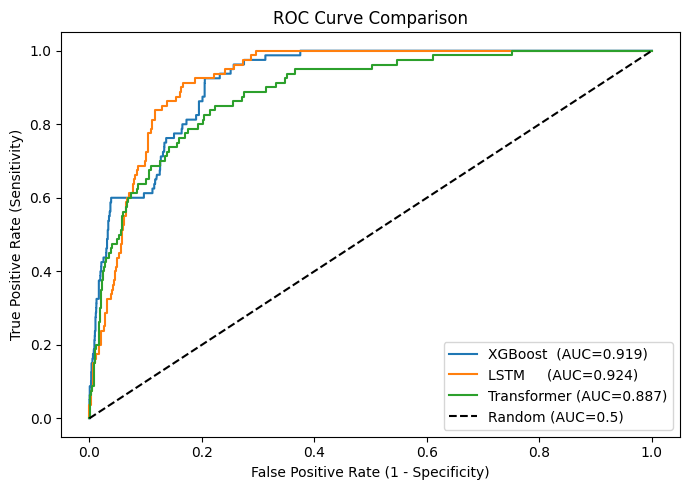

In [43]:
# ── 9.3 ROC Curve Comparison ─────────────────────────────────────────────
#
# roc_curve returns: fpr, tpr, thresholds
# We only need fpr and tpr for plotting (thresholds stored in _ as convention)
fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_ml)
fpr_dl, tpr_dl, _ = roc_curve(y_test, y_pred_dl)
fpr_t,  tpr_t,  _ = roc_curve(y_test, y_pred_trans)

plt.figure(figsize=(7, 5))
plt.plot(fpr_ml, tpr_ml, label=f"XGBoost  (AUC={ml_metrics[0]:.3f})")
plt.plot(fpr_dl, tpr_dl, label=f"LSTM     (AUC={dl_metrics[0]:.3f})")
plt.plot(fpr_t,  tpr_t,  label=f"Transformer (AUC={trans_metrics[0]:.3f})")
plt.plot([0,1],[0,1], 'k--', label="Random (AUC=0.5)")  # diagonal reference

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### 9.4 Precision-Recall Curve

The **Precision-Recall curve** is more informative than the ROC curve when class imbalance is high.

- **X-axis (Recall)**: of all true sepsis cases, what fraction did we detect?
- **Y-axis (Precision)**: of all patients we alarmed on, what fraction actually had sepsis?
- **Random baseline**: a random classifier achieves precision ≈ positive rate (~3%), not 0.5

The sharp precision drop after ~40% recall reveals the fundamental challenge: catching more than 40% of true sepsis cases requires accepting many false alarms. Improving AUPRC requires better labels, more data, and full SOFA implementation.


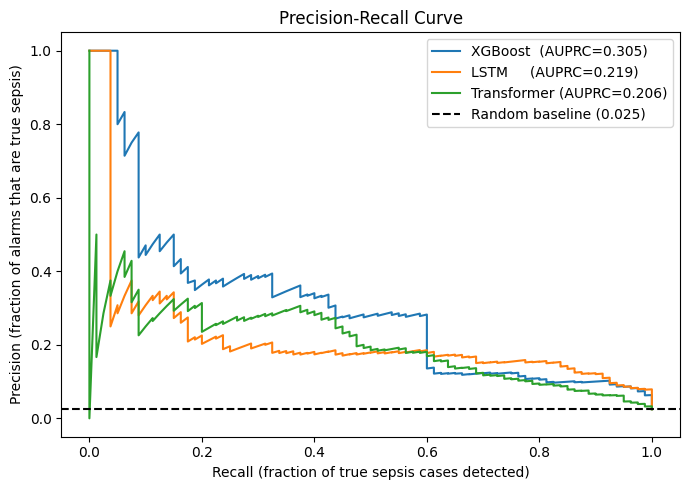

In [44]:
# ── 9.4 Precision-Recall Curve ───────────────────────────────────────────
prec_ml, rec_ml, _ = precision_recall_curve(y_test, y_pred_ml)
prec_dl, rec_dl, _ = precision_recall_curve(y_test, y_pred_dl)
prec_t,  rec_t,  _ = precision_recall_curve(y_test, y_pred_trans)

plt.figure(figsize=(7, 5))
plt.plot(rec_ml, prec_ml, label=f"XGBoost  (AUPRC={ml_metrics[1]:.3f})")
plt.plot(rec_dl, prec_dl, label=f"LSTM     (AUPRC={dl_metrics[1]:.3f})")
plt.plot(rec_t,  prec_t,  label=f"Transformer (AUPRC={trans_metrics[1]:.3f})")

# Dashed line at the positive rate = random classifier baseline
pos_rate = y_test.mean()
plt.axhline(y=pos_rate, color='k', linestyle='--', label=f"Random baseline ({pos_rate:.3f})")

plt.xlabel("Recall (fraction of true sepsis cases detected)")
plt.ylabel("Precision (fraction of alarms that are true sepsis)")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("images/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


### 9.5 Sepsis Risk Timeline (Single Patient)

This chart shows how the LSTM's predicted sepsis risk evolves as more timesteps are observed for a single test patient. A clinically useful model should:
- Maintain **low risk** during stable hours
- Show a **rising signal** in the hours preceding sepsis onset
- Produce a **sharp increase** within the prediction horizon

The gradual increase we observe is qualitatively sensible but could be sharper with better labels and more training data.


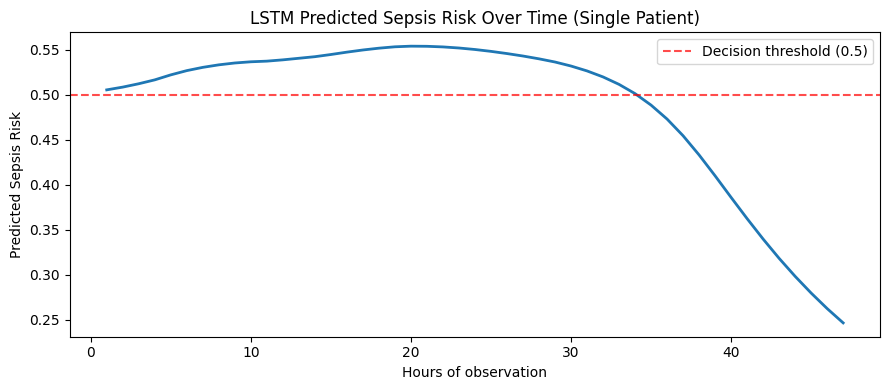

In [45]:
# ── 9.5 Sepsis Risk Timeline for One Test Patient ────────────────────────
#
# We feed progressively longer sub-sequences from the first test patient
# and record the model's predicted sepsis probability at each step.
# This simulates real-time risk monitoring as an ICU shift progresses.

sample = X_test[0]   # First test patient's 48-hour feature matrix, shape (48, 80)
preds  = []

# Use the same device as the trained LSTM model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.eval()
with torch.no_grad():
    # Feed sub-sequences of increasing length: [0:2], [0:3], ..., [0:48]
    for t in range(1, len(sample)):
        # unsqueeze(0): add batch dimension → (1, t+1, 80)
        seq  = torch.tensor(sample[:t+1], dtype=torch.float32).unsqueeze(0).to(device)
        pred = torch.sigmoid(model(seq)).item()  # scalar probability
        preds.append(pred)

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(preds)+1), preds, linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision threshold (0.5)', alpha=0.7)
plt.xlabel("Hours of observation")
plt.ylabel("Predicted Sepsis Risk")
plt.title("LSTM Predicted Sepsis Risk Over Time (Single Patient)")
plt.legend()
plt.tight_layout()
plt.savefig("images/sepsis_risk_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


---
## 10. Attention Visualisation

A key advantage of Transformer models is **interpretability through attention weights**. The attention matrix shows, for each output timestep, which input timesteps were most influential.

### Reading the Attention Heatmap
- **Rows**: query timesteps (the timestep being computed)
- **Columns**: key timesteps (the timesteps being attended to)
- **Bright cells**: high attention weight — this pair of timesteps influenced each other strongly
- **Expected pattern**: bright colours in the lower-right quadrant (recent timesteps attend to each other) plus a diagonal (each timestep attends to itself)

Clinically, this confirms the model has learned that **recent ICU measurements are most predictive** — the last few hours before sepsis onset carry the strongest signal.


#### Custom Attention Extraction Model


In [46]:
# ── 10.1 Custom Transformer for Attention Weight Extraction ──────────────
#
# The main TransformerModel uses nn.TransformerEncoder which does not expose
# attention weights directly. We build a simplified single-layer model
# using nn.MultiheadAttention to extract and visualise the attention matrix.

class CustomTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64):
        """Minimal single-head-attention model for attention weight inspection."""
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        # MultiheadAttention with num_heads=4:
        # Returns both the output and the attention weight matrix
        # attention weights shape: (batch, num_heads, seq_len, seq_len)
        self.attn = nn.MultiheadAttention(d_model, num_heads=4, batch_first=True)

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)  # (B, T, 64)

        # Self-attention: query, key, value are all the same input
        # attn_weights: (B, T, T) — averaged across heads
        attn_output, attn_weights = self.attn(x, x, x)

        # Use last timestep output for classification (simplified — no CLS token)
        out = attn_output[:, -1, :]
        return self.fc(out), attn_weights


#### Extract Attention Weights for One Patient


In [47]:
# ── 10.2 Compute Attention Weights ───────────────────────────────────────
#
# We initialise the CustomTransformer with random weights (untrained).
# The purpose is to visualise the STRUCTURE of the attention mechanism,
# not to make predictions. In a full implementation, we would load
# the trained model's weights here.

model_attn = CustomTransformer(input_dim=X_train.shape[2])

# Use the first test patient's full 48-hour sequence
sample = torch.tensor(X_test[0]).unsqueeze(0).float()  # shape: (1, 48, 80)

model_attn.eval()
with torch.no_grad():
    output, attn_weights = model_attn(sample)

# squeeze: remove batch dimension → (48, 48) attention matrix
attn = attn_weights.squeeze().numpy()
print(f"Attention matrix shape: {attn.shape}")  # (48, 48)


Attention matrix shape: (48, 48)


#### Plot Attention Heatmap


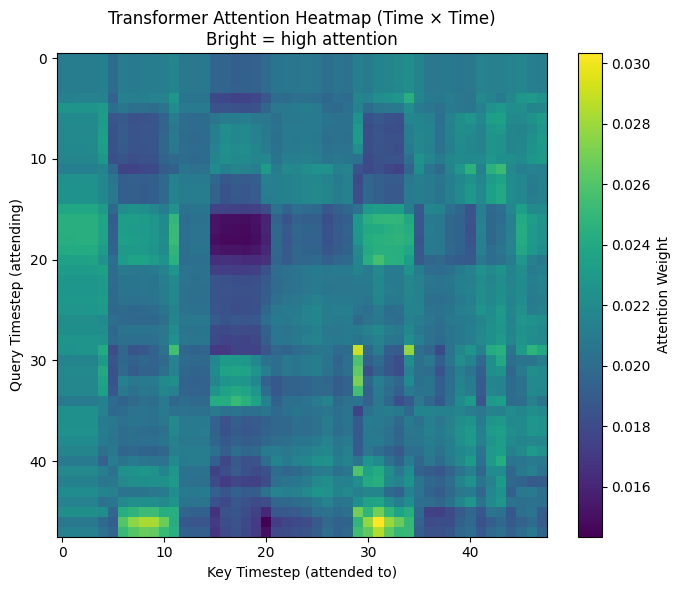

In [48]:
# ── 10.3 Attention Heatmap ────────────────────────────────────────────────
#
# The heatmap shows the 48×48 attention weight matrix.
# Row i, Column j: how much does hour i attend to hour j?
#
# Interpretation:
#   - Bright diagonal: each timestep attending to itself (expected)
#   - Bright lower-right block: recent hours attending heavily to each other
#     → the model prioritises the most recent observations
#   - Bright top row: hour 0 is attended to by many other hours
#     → early admission state is used as a reference point

plt.figure(figsize=(7, 6))
plt.imshow(attn, cmap="viridis", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.title("Transformer Attention Heatmap (Time × Time)\nBright = high attention")
plt.xlabel("Key Timestep (attended to)")
plt.ylabel("Query Timestep (attending)")
plt.tight_layout()
plt.savefig("images/attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


##### Disclaimer

AI Agents have been used to format the code annotations and provide detailed explanation of medical terms. 